In [7]:
import pandas as pd

In [8]:
df=pd.read_csv("stock_analysis_100_records.csv")

In [9]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047
...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    100 non-null    object 
 1   Open    100 non-null    float64
 2   High    100 non-null    float64
 3   Low     100 non-null    float64
 4   Close   100 non-null    float64
 5   Volume  100 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [11]:
df["Date"]= pd.to_datetime(df["Date"])

In [12]:
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

In [39]:
df=df.sort_values("Date") # sort by date
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50,Daily_return
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN,-0.150000
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN,1.271908
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN,2.838212
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN,-0.326955
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316,-2.531068
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552,0.631653
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546,0.569569
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434,0.104022


In [40]:
df["MA_20"]=df["Close"].rolling(20).mean() #calculate moving avg
df["MA_50"]=df["Close"].rolling(50).mean()
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50,Daily_return
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN,-0.150000
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN,1.271908
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN,2.838212
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN,-0.326955
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316,-2.531068
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552,0.631653
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546,0.569569
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434,0.104022


In [41]:
df["Daily_return"]=df["Close"].pct_change()*100 #calculate Daily_return
df

,Date,Open,High,Low,Close,Volume,MA_20,MA_50,Daily_return
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,NaN,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,NaN,NaN,-0.150000
2,2026-01-07,99.60,102.35,99.35,101.12,760093,NaN,NaN,1.271908
3,2026-01-08,100.91,104.43,99.89,103.99,850786,NaN,NaN,2.838212
4,2026-01-09,103.49,104.70,102.45,103.65,857047,NaN,NaN,-0.326955
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,87.9065,87.3316,-2.531068
96,2026-05-19,85.69,86.89,85.45,86.03,930836,87.6480,87.3552,0.631653
97,2026-05-20,85.57,87.85,84.48,86.52,694413,87.4340,87.3546,0.569569
98,2026-05-21,86.60,87.14,86.50,86.61,821449,87.2125,87.3434,0.104022


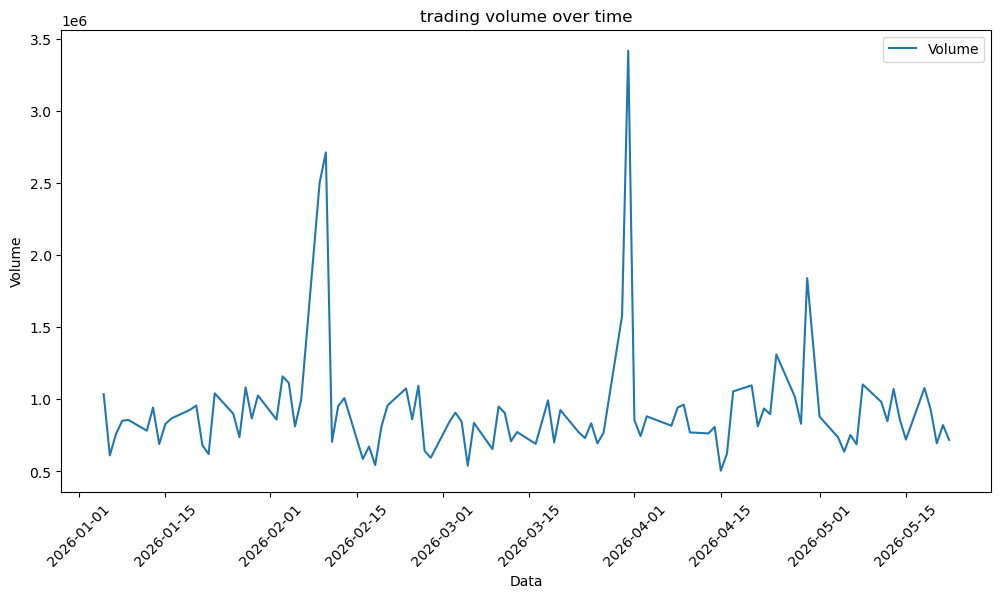

In [42]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"],df["Volume"],label="Volume")


plt.title("trading volume over time")
plt.xlabel("Data")
plt.ylabel("Volume")
plt.legend()
plt.xticks(rotation=45)
plt.show()         

In [43]:
import matplotlib.pyplot as plt

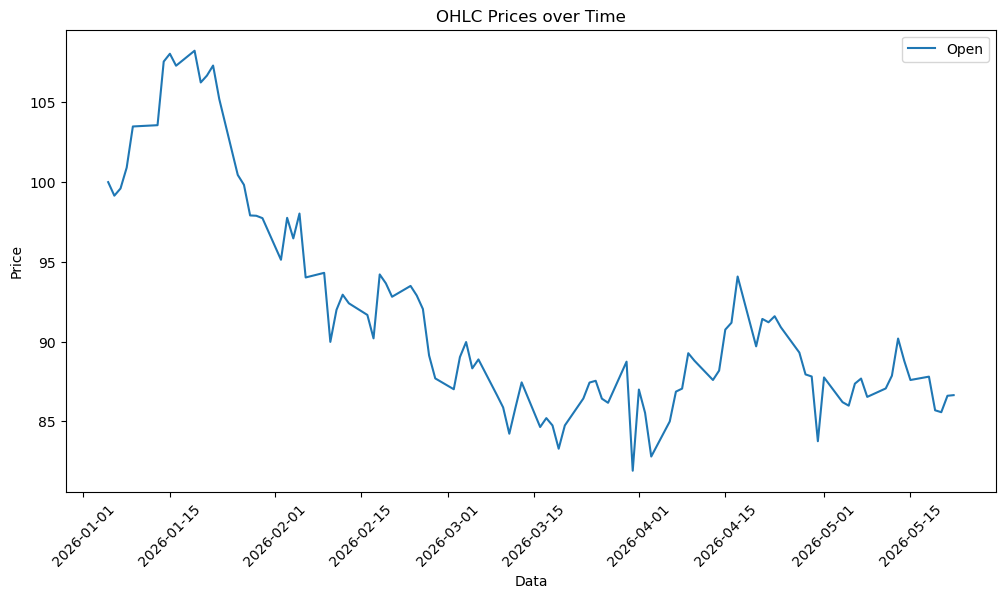

In [44]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"],df["Open"],label="Open")


plt.title("OHLC Prices over Time")
plt.xlabel("Data")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()         

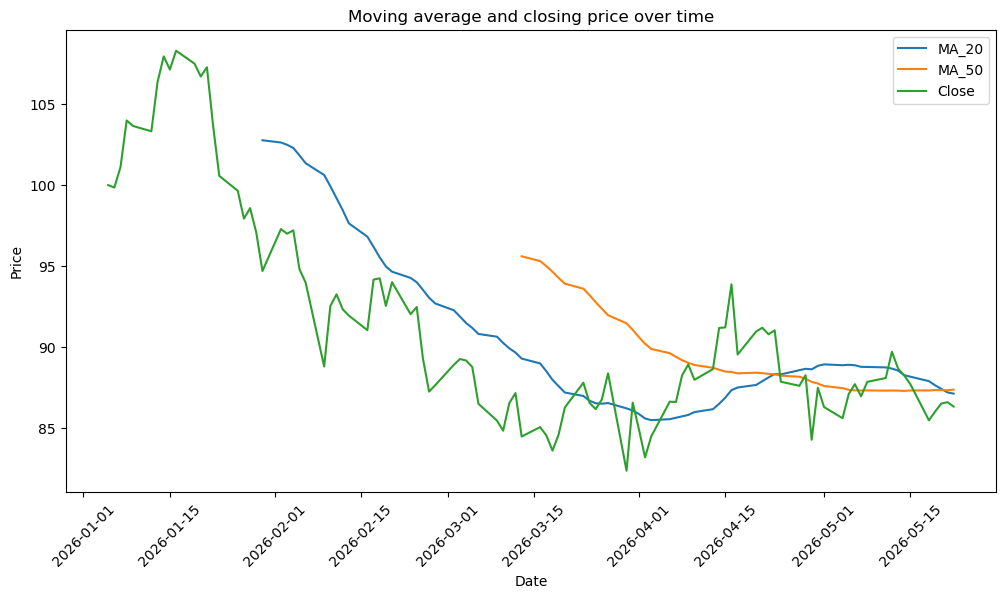

In [45]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["MA_20"],label="MA_20")
plt.plot(df["Date"],df["MA_50"],label="MA_50")
plt.plot(df["Date"],df["Close"],label="Close")
plt.title("Moving average and closing price over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [46]:
import seaborn as sns

C:\Users\Dell\AppData\Local\Temp\ipykernel_26572\686179006.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


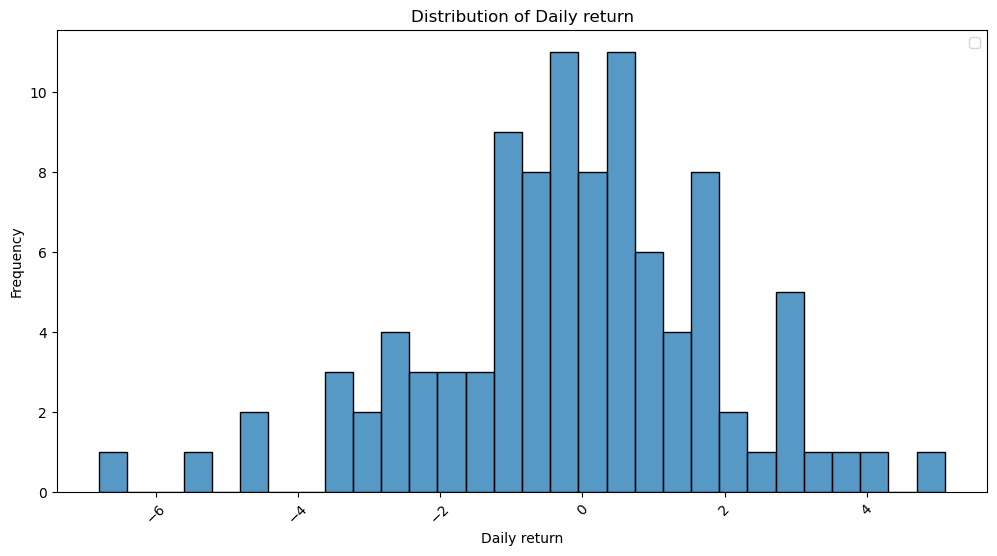

In [47]:
plt.figure(figsize=(12,6))

sns.histplot(df["Daily_return"],bins=30)

plt.title("Distribution of Daily return")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.legend()
plt.xticks(rotation=45)
plt.show()     

C:\Users\Dell\AppData\Local\Temp\ipykernel_26572\1831335811.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


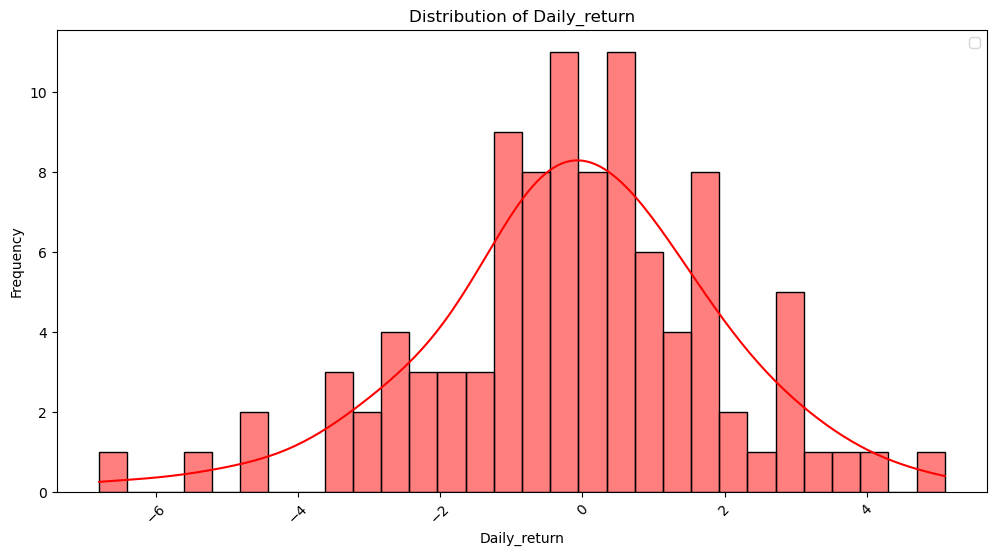

In [48]:
plt.figure(figsize=(12,6))

sns.histplot(df["Daily_return"],bins=30,kde=True,color="RED")

plt.title("Distribution of Daily_return")
plt.xlabel("Daily_return")
plt.ylabel("Frequency")
plt.legend()
plt.xticks(rotation=45)
plt.show()     

In [ ]:
Daily_return=df["Daily_return"]
Average_return=Daily_return.mean()
variance=Daily_return.var()
std_deviation=Daily_return.std()
max_return=Daily_return.max()
min_return=Daily_return.min()

print("FINANCIAL SUMMERY")
print("_"*25)
print("Average Daily_return:", Daily_return)
print("variance:", variance)
print("Standard deviation:", std_deviation)
print("Maxium Daily_return:", 